In [1]:
# Import Relevant Libraries
import math
import matplotlib.pyplot as plt
%matplotlib inline 
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix,f1_score,accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import StackingClassifier

# 1.Loading the dataset 

In [2]:
df=pd.read_csv('C://Users/Admin4/Desktop/VIT/3rd year fall sem 22-23/MHA3011-Intelligent Systems and Control/PROJECT/Python codes/PARKINSONS.csv')
df.head()

,ID,Recording,Status,Gender,Jitter_rel,Jitter_abs,Jitter_RAP,Jitter_PPQ,Shim_loc,Shim_dB,...,Delta3,Delta4,Delta5,Delta6,Delta7,Delta8,Delta9,Delta10,Delta11,Delta12
0,CONT-01,1,0,1,0.25546,0.000015,0.001467,0.001673,0.030256,0.26313,...,1.407701,1.417218,1.380352,1.420670,1.451240,1.440295,1.403678,1.405495,1.416705,1.354610
1,CONT-02,1,0,0,0.29320,0.000017,0.001105,0.001444,0.024716,0.20892,...,1.501200,1.534170,1.323993,1.496442,1.472926,1.643177,1.551286,1.638346,1.604008,1.621456
2,CONT-03,1,0,1,0.22506,0.000014,0.001358,0.001460,0.017181,0.14812,...,1.712147,1.419443,1.501822,1.503534,1.486685,1.648505,1.345959,1.741863,1.828781,1.655604
3,CONT-04,1,0,1,1.31000,0.000103,0.008245,0.006280,0.030742,0.27064,...,1.541010,1.347021,1.526148,1.428505,1.516130,1.491684,1.579521,1.374581,1.550638,1.572821
4,CONT-05,1,0,0,0.78955,0.000103,0.004238,0.004574,0.039162,0.33289,...,1.346048,1.221651,1.441105,1.518406,1.584300,1.628549,1.385665,1.426097,1.515076,1.305066


# 2.Eyeball the data to make observations:


In [3]:
print("Null value Check\n")
print(df.isnull().sum())
print("\n\n NAN values Check\n")
print(df.isna().sum())

Null value Check

ID            0
Recording     0
Status        0
Gender        0
Jitter_rel    0
Jitter_abs    0
Jitter_RAP    0
Jitter_PPQ    0
Shim_loc      0
Shim_dB       0
Shim_APQ3     0
Shim_APQ5     0
Shi_APQ11     0
HNR05         0
HNR15         0
HNR25         0
HNR35         0
HNR38         0
RPDE          0
DFA           0
PPE           0
GNE           0
MFCC0         0
MFCC1         0
MFCC2         0
MFCC3         0
MFCC4         0
MFCC5         0
MFCC6         0
MFCC7         0
MFCC8         0
MFCC9         0
MFCC10        0
MFCC11        0
MFCC12        0
Delta0        0
Delta1        0
Delta2        0
Delta3        0
Delta4        0
Delta5        0
Delta6        0
Delta7        0
Delta8        0
Delta9        0
Delta10       0
Delta11       0
Delta12       0
dtype: int64


 NAN values Check

ID            0
Recording     0
Status        0
Gender        0
Jitter_rel    0
Jitter_abs    0
Jitter_RAP    0
Jitter_PPQ    0
Shim_loc      0
Shim_dB       0
Shim_APQ3     0
Shim

# Observation:No missing values in the data

# Removing ID,Recording number,Gender as they have no effect on the final output.

In [4]:
df=df.drop(['ID','Recording','Gender'],axis=1)
df

,Status,Jitter_rel,Jitter_abs,Jitter_RAP,Jitter_PPQ,Shim_loc,Shim_dB,Shim_APQ3,Shim_APQ5,Shi_APQ11,...,Delta3,Delta4,Delta5,Delta6,Delta7,Delta8,Delta9,Delta10,Delta11,Delta12
0,0,0.25546,0.000015,0.001467,0.001673,0.030256,0.26313,0.017463,0.019660,0.021882,...,1.407701,1.417218,1.380352,1.420670,1.451240,1.440295,1.403678,1.405495,1.416705,1.354610
1,0,0.29320,0.000017,0.001105,0.001444,0.024716,0.20892,0.014525,0.015696,0.018330,...,1.501200,1.534170,1.323993,1.496442,1.472926,1.643177,1.551286,1.638346,1.604008,1.621456
2,0,0.22506,0.000014,0.001358,0.001460,0.017181,0.14812,0.009609,0.011060,0.012707,...,1.712147,1.419443,1.501822,1.503534,1.486685,1.648505,1.345959,1.741863,1.828781,1.655604
3,0,1.31000,0.000103,0.008245,0.006280,0.030742,0.27064,0.018590,0.016261,0.020322,...,1.541010,1.347021,1.526148,1.428505,1.516130,1.491684,1.579521,1.374581,1.550638,1.572821
4,0,0.78955,0.000103,0.004238,0.004574,0.039162,0.33289,0.021275,0.024791,0.034528,...,1.346048,1.221651,1.441105,1.518406,1.584300,1.628549,1.385665,1.426097,1.515076,1.305066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,1,0.71988,0.000032,0.004559,0.003665,0.044262,0.36809,0.025824,0.024782,0.030001,...,0.992847,1.001799,0.969471,0.997726,0.982584,0.991522,0.969025,1.040096,0.992941,0.974730
236,1,1.17830,0.000070,0.007112,0.006334,0.149110,1.37560,0.093485,0.077903,0.084238,...,1.262602,1.267017,1.255716,1.252483,1.275054,1.314755,1.372089,1.355118,1.337585,1.391346
237,1,0.24443,0.000015,0.001375,0.001540,0.033357,0.28749,0.019713,0.019954,0.021625,...,1.145621,1.112572,1.081933,1.099118,1.106177,1.117381,1.114905,1.149443,1.117868,1.091054
238,1,0.23322,0.000015,0.001270,0.001497,0.017923,0.16720,0.008436,0.011578,0.015473,...,1.107477,1.083859,1.101819,1.114161,1.090095,1.140705,1.126667,1.158444,1.096073,1.141835


In [5]:
df.dtypes

Status          int64
Jitter_rel    float64
Jitter_abs    float64
Jitter_RAP    float64
Jitter_PPQ    float64
Shim_loc      float64
Shim_dB       float64
Shim_APQ3     float64
Shim_APQ5     float64
Shi_APQ11     float64
HNR05         float64
HNR15         float64
HNR25         float64
HNR35         float64
HNR38         float64
RPDE          float64
DFA           float64
PPE           float64
GNE           float64
MFCC0         float64
MFCC1         float64
MFCC2         float64
MFCC3         float64
MFCC4         float64
MFCC5         float64
MFCC6         float64
MFCC7         float64
MFCC8         float64
MFCC9         float64
MFCC10        float64
MFCC11        float64
MFCC12        float64
Delta0        float64
Delta1        float64
Delta2        float64
Delta3        float64
Delta4        float64
Delta5        float64
Delta6        float64
Delta7        float64
Delta8        float64
Delta9        float64
Delta10       float64
Delta11       float64
Delta12       float64
dtype: obj

In [6]:
cols=df.columns[:]
print(cols)
print("Number of features:",len(cols))

Index(['Status', 'Jitter_rel', 'Jitter_abs', 'Jitter_RAP', 'Jitter_PPQ',
       'Shim_loc', 'Shim_dB', 'Shim_APQ3', 'Shim_APQ5', 'Shi_APQ11', 'HNR05',
       'HNR15', 'HNR25', 'HNR35', 'HNR38', 'RPDE', 'DFA', 'PPE', 'GNE',
       'MFCC0', 'MFCC1', 'MFCC2', 'MFCC3', 'MFCC4', 'MFCC5', 'MFCC6', 'MFCC7',
       'MFCC8', 'MFCC9', 'MFCC10', 'MFCC11', 'MFCC12', 'Delta0', 'Delta1',
       'Delta2', 'Delta3', 'Delta4', 'Delta5', 'Delta6', 'Delta7', 'Delta8',
       'Delta9', 'Delta10', 'Delta11', 'Delta12'],
      dtype='object')
Number of features: 45


# Observation: All the data are floating point numbers with the exception of "status" which is 0 or 1 and hence an integer

In [7]:
rows=df.count(axis=0)[0]
print("Number of rows:",rows)

Number of rows: 240


# Number and percentage of parkinsons disease patients

In [8]:
numpark = df[df["Status"] == 1].Status.count()
print("Number of Parkinsons Patients:\n", numpark)
print("Percentage of patients with PD:\n", round((numpark * 100)/rows))

Number of Parkinsons Patients:
 120
Percentage of patients with PD:
 50


# Data is equal between having PD and not having PD.

# 3.Studying the data distribution

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Status,240.0,0.500000,0.501045,0.000000,0.000000,0.500000,1.000000,1.000000
Jitter_rel,240.0,0.583987,0.535769,0.148010,0.298260,0.481455,0.681685,6.838200
Jitter_abs,240.0,0.000044,0.000045,0.000007,0.000019,0.000035,0.000056,0.000550
Jitter_RAP,240.0,0.003172,0.003373,0.000678,0.001551,0.002337,0.003678,0.043843
Jitter_PPQ,240.0,0.003532,0.004449,0.001036,0.001867,0.002870,0.003991,0.065199
Shim_loc,240.0,0.038428,0.023213,0.007444,0.024336,0.032960,0.045475,0.192600
Shim_dB,240.0,0.336832,0.205905,0.064989,0.211785,0.287885,0.399860,1.747600
Shim_APQ3,240.0,0.021499,0.013787,0.003344,0.012910,0.018571,0.025784,0.113240
Shim_APQ5,240.0,0.023468,0.014402,0.004103,0.014985,0.019897,0.027900,0.120760
Shi_APQ11,240.0,0.028671,0.016610,0.006459,0.019180,0.024909,0.033757,0.142440


# Plotting an array of boxplots to see distributions and outliers

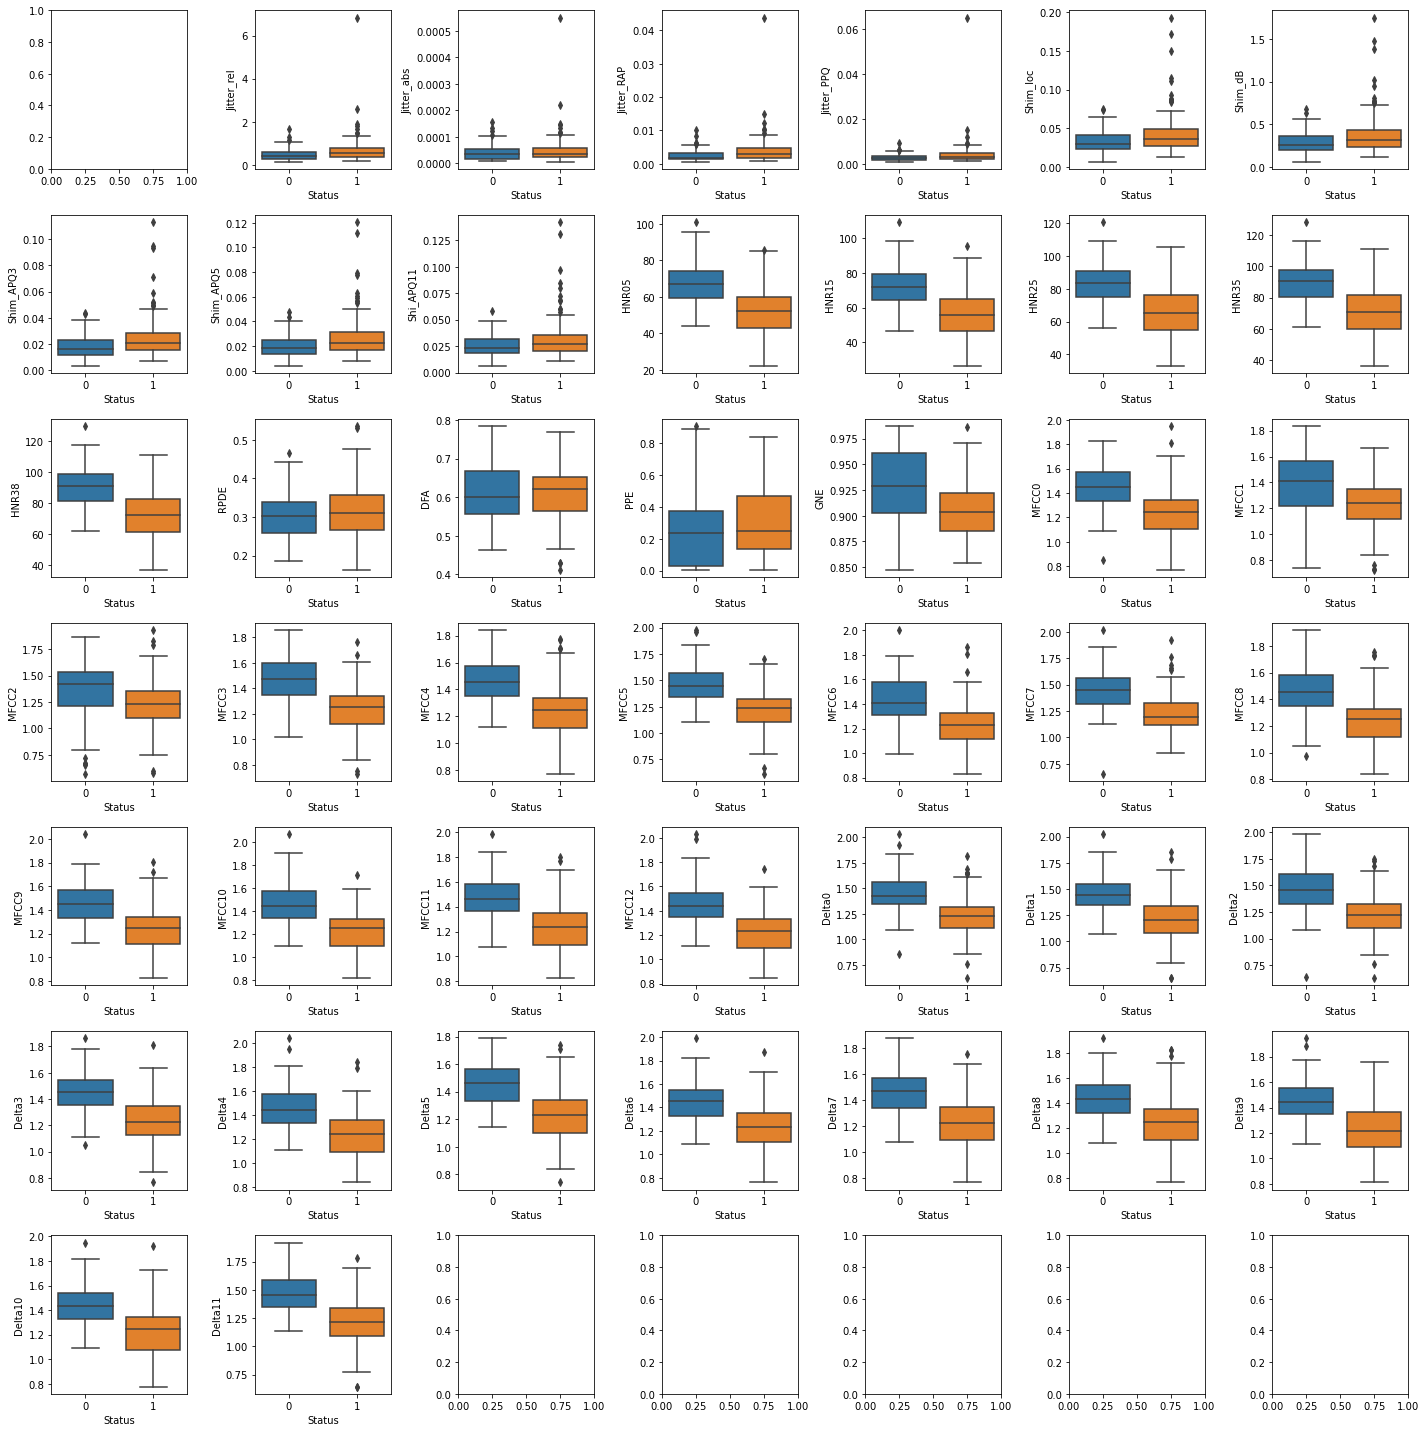

In [10]:
fig,axes=plt.subplots(7,7,figsize=(20,20))
axes=axes.flatten()

for i in range(1,len(df.columns)-1):
    sns.boxplot(x='Status',y=df.iloc[:,i],data=df,orient='v',ax=axes[i])
plt.tight_layout()
plt.show()

# Creating a correlation function to filter out and remove features having a high correlation.

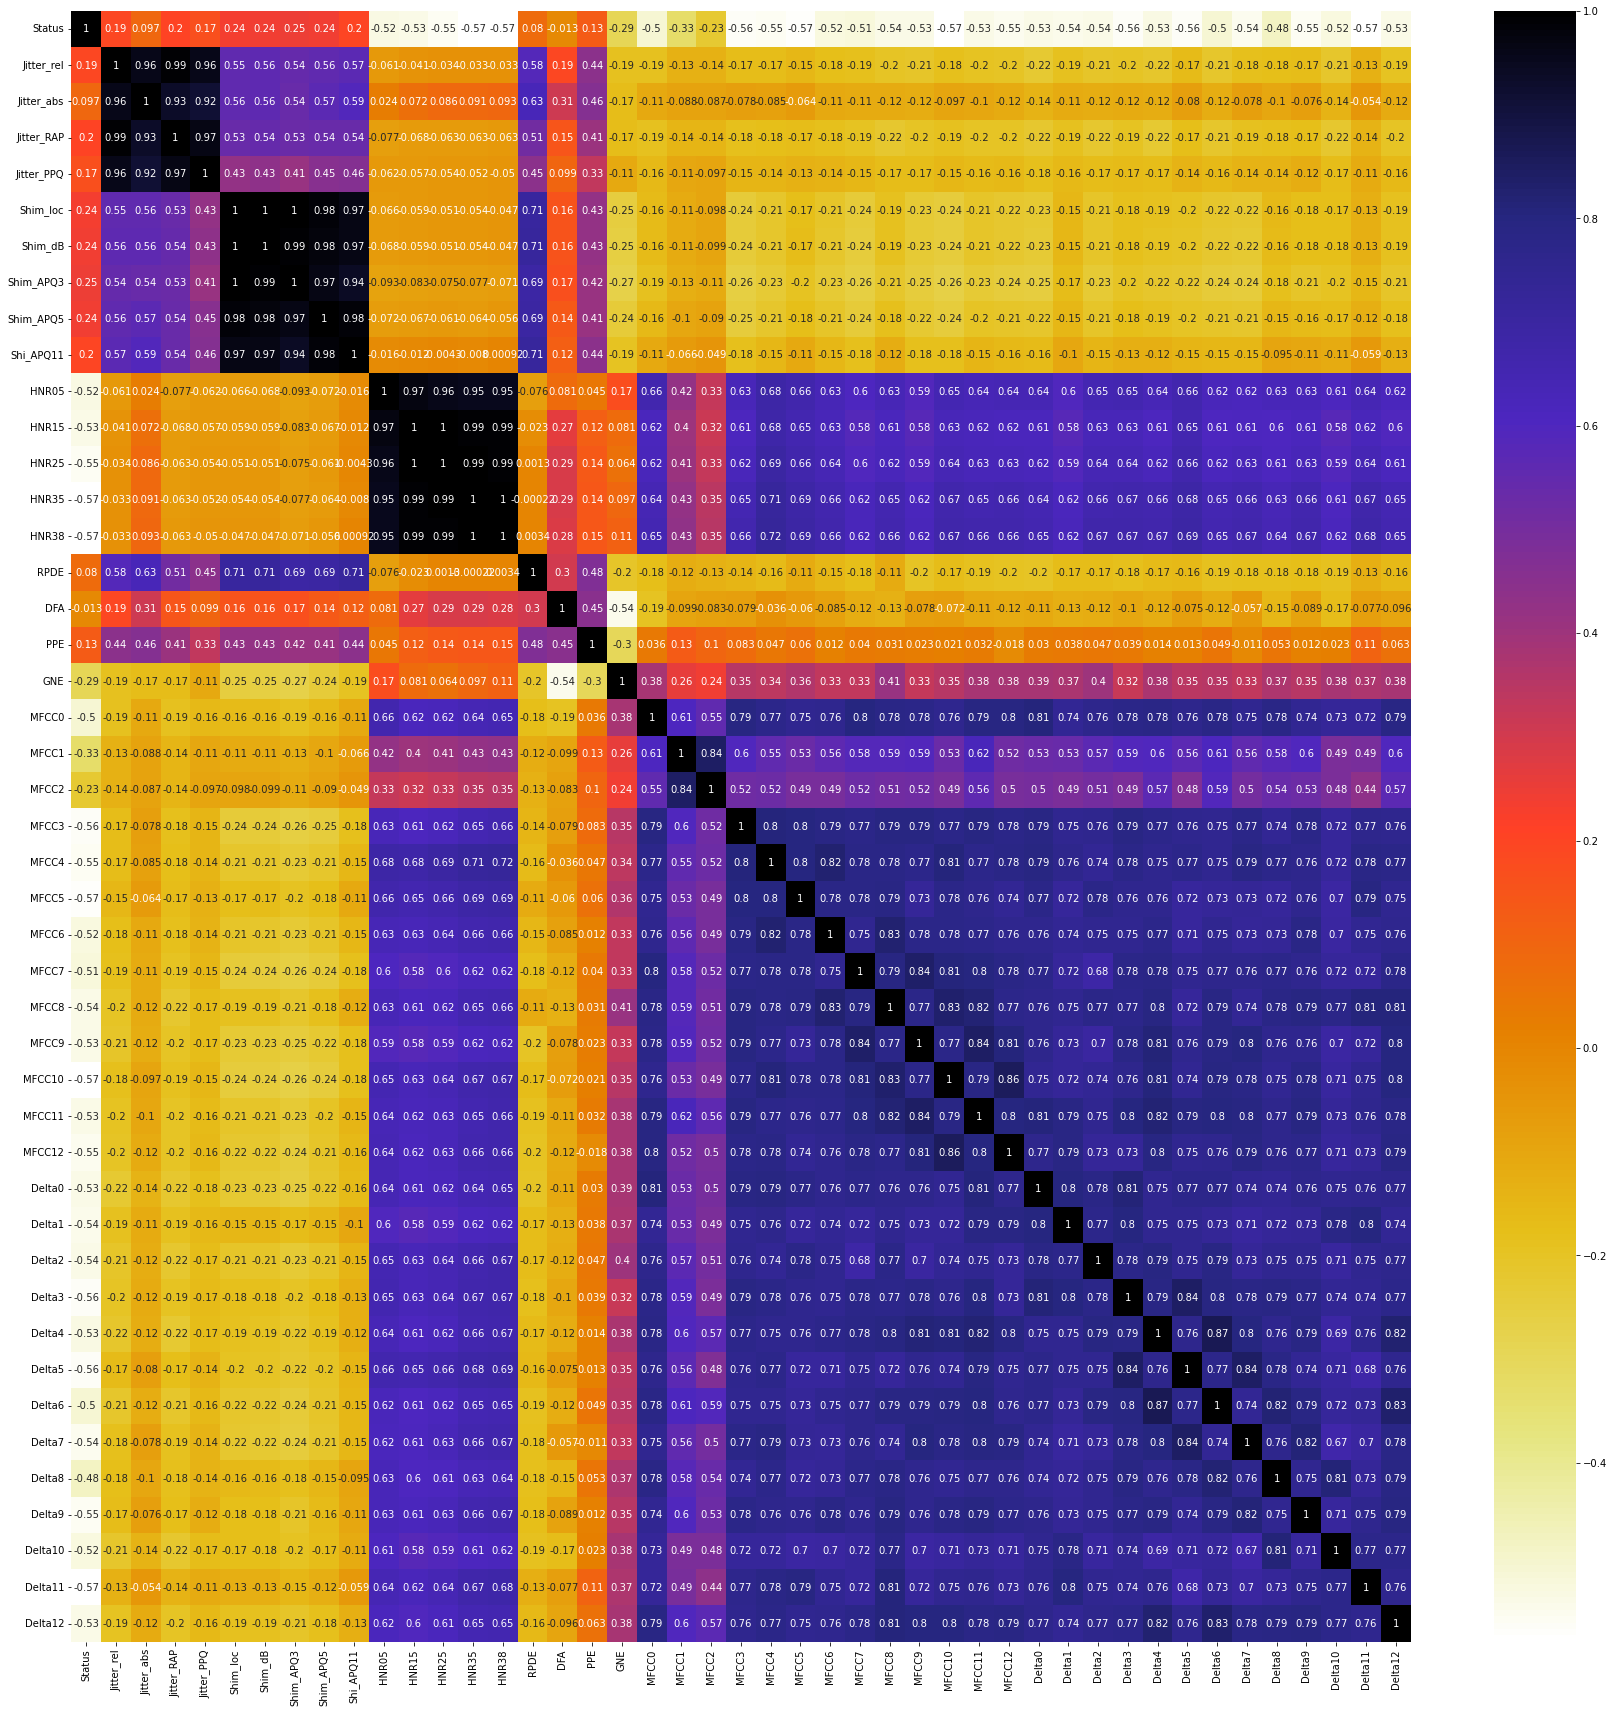

In [11]:
plt.figure(figsize=(30,30))
cor=df.corr()
sns.heatmap(cor,annot=True,cmap=plt.cm.CMRmap_r)
plt.show()

In [12]:
def correlation(dataset,threshold):
    col_corr=set()                 #set of all the names of correlated columns
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (corr_matrix.iloc[i,j])>threshold:    #absolute value of coefficient
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [13]:
corr_features=correlation(df,0.85)
len(set(corr_features))

13

In [14]:
corr_features

{'Delta6',
 'HNR15',
 'HNR25',
 'HNR35',
 'HNR38',
 'Jitter_PPQ',
 'Jitter_RAP',
 'Jitter_abs',
 'MFCC12',
 'Shi_APQ11',
 'Shim_APQ3',
 'Shim_APQ5',
 'Shim_dB'}

# Studying the distribution of parameters:

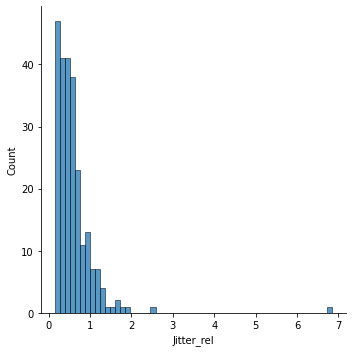

In [15]:
sns.displot(df["Jitter_rel"])

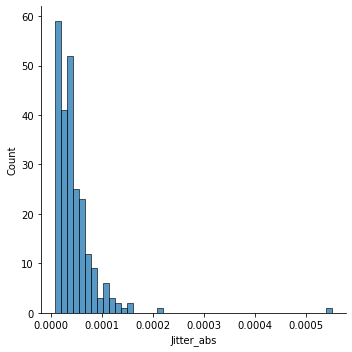

In [16]:
sns.displot(df["Jitter_abs"])

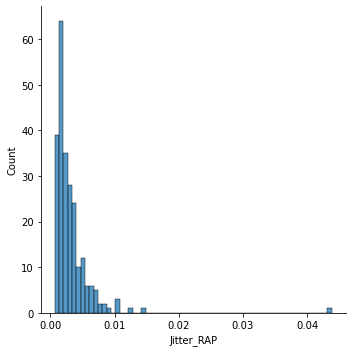

In [17]:
sns.displot(df["Jitter_RAP"])

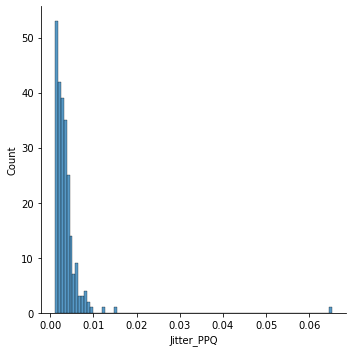

In [18]:
sns.displot(df["Jitter_PPQ"])

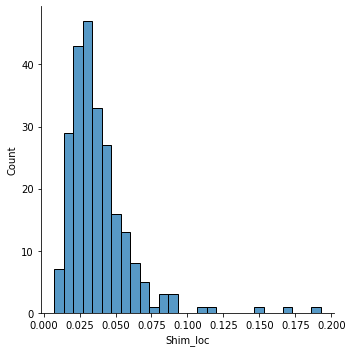

In [19]:
sns.displot(df["Shim_loc"])

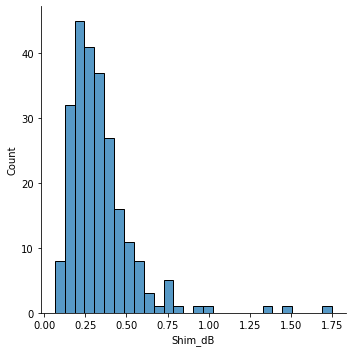

In [20]:
sns.displot(df["Shim_dB"])

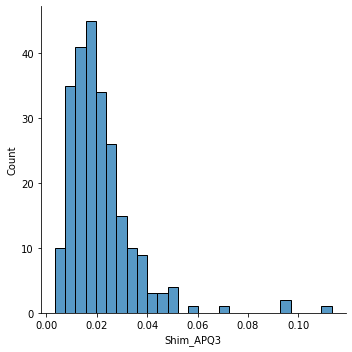

In [21]:
sns.displot(df["Shim_APQ3"])

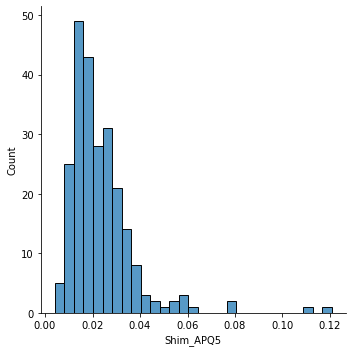

In [22]:
sns.displot(df["Shim_APQ5"])

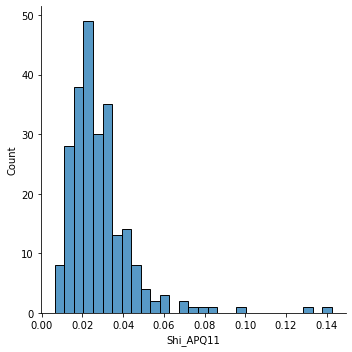

In [23]:
sns.displot(df["Shi_APQ11"])

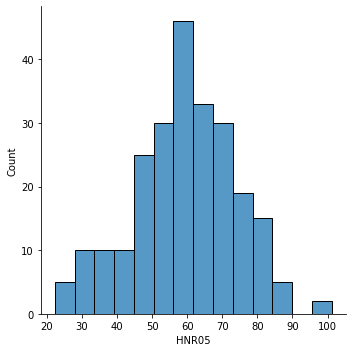

In [24]:
sns.displot(df["HNR05"])

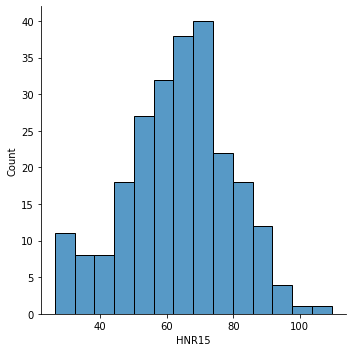

In [25]:
sns.displot(df["HNR15"])

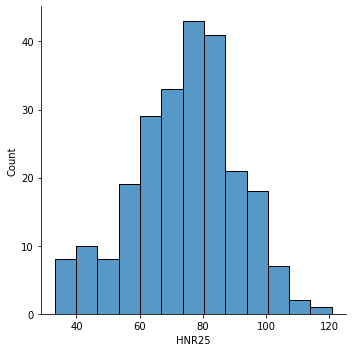

In [26]:
sns.displot(df["HNR25"])

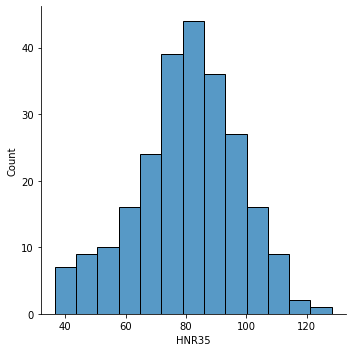

In [27]:
sns.displot(df["HNR35"])

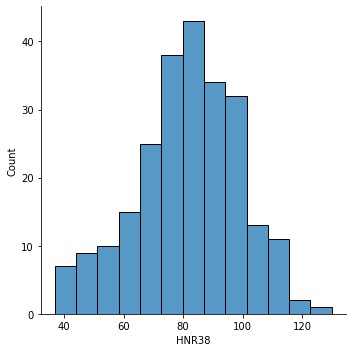

In [28]:
sns.displot(df["HNR38"])

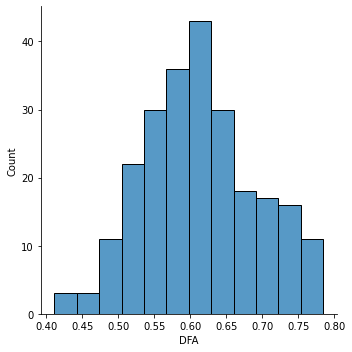

In [29]:
sns.displot(df["DFA"])

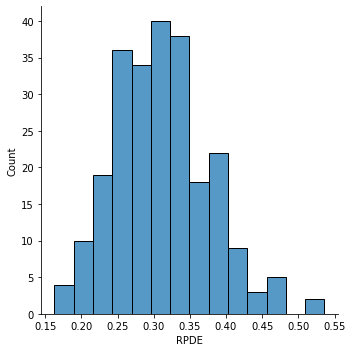

In [30]:
sns.displot(df["RPDE"])

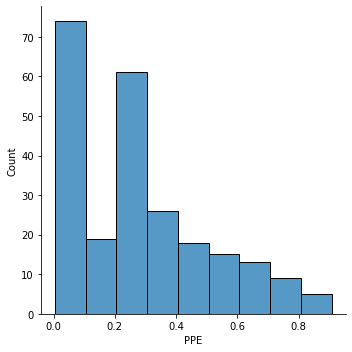

In [31]:
sns.displot(df["PPE"])

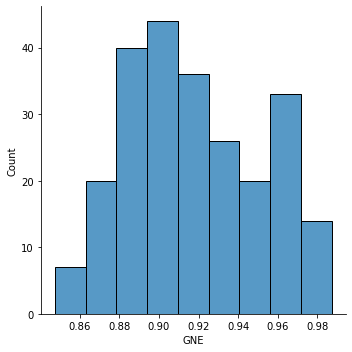

In [32]:
sns.displot(df["GNE"])

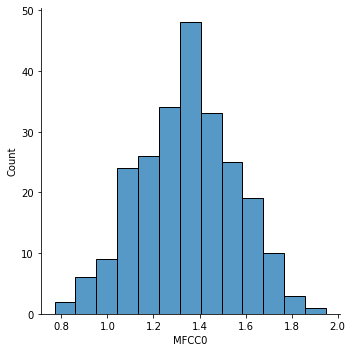

In [33]:
sns.displot(df["MFCC0"])

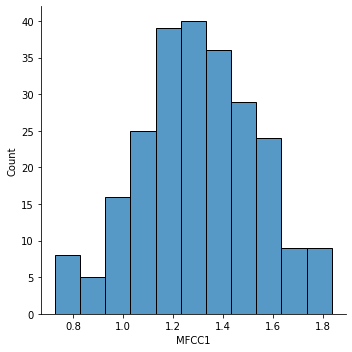

In [34]:
sns.displot(df["MFCC1"])

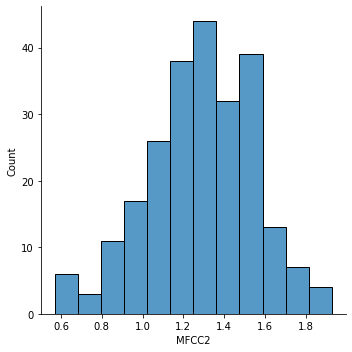

In [35]:
sns.displot(df["MFCC2"])

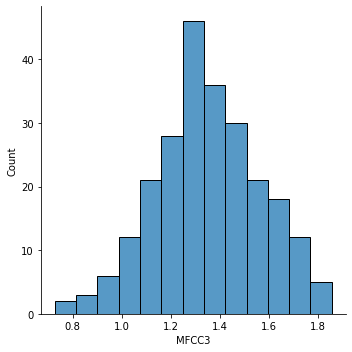

In [36]:
sns.displot(df["MFCC3"])

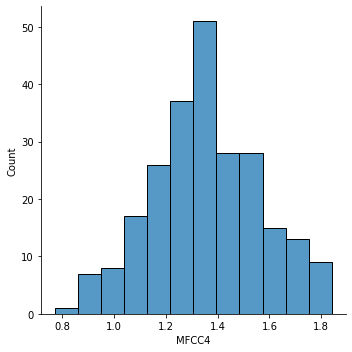

In [37]:
sns.displot(df["MFCC4"])

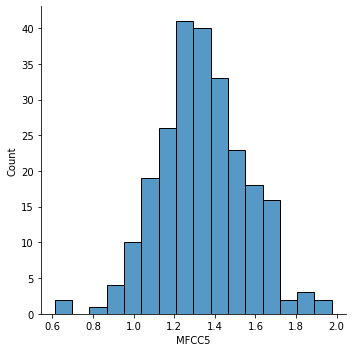

In [38]:
sns.displot(df["MFCC5"])

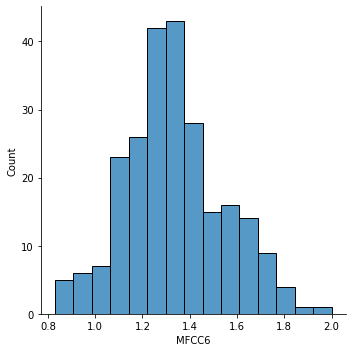

In [39]:
sns.displot(df["MFCC6"])

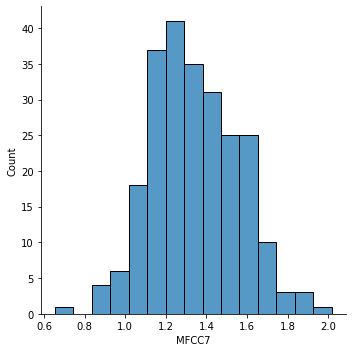

In [40]:
sns.displot(df["MFCC7"])

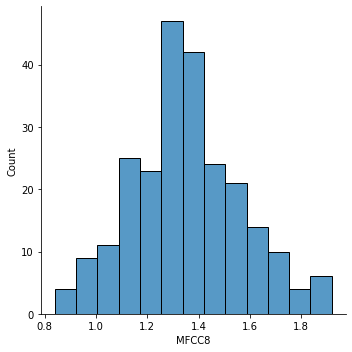

In [41]:
sns.displot(df["MFCC8"])

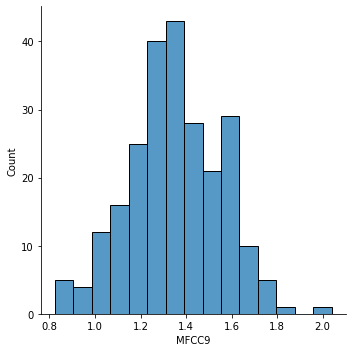

In [42]:
sns.displot(df["MFCC9"])

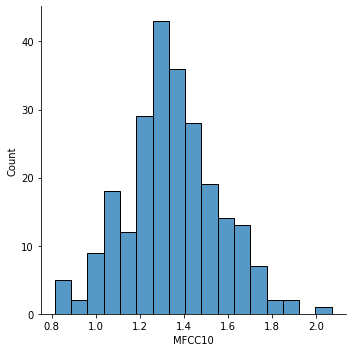

In [43]:
sns.displot(df["MFCC10"])

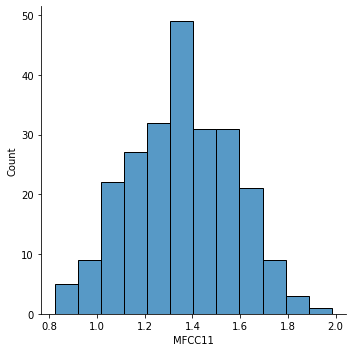

In [44]:
sns.displot(df["MFCC11"])

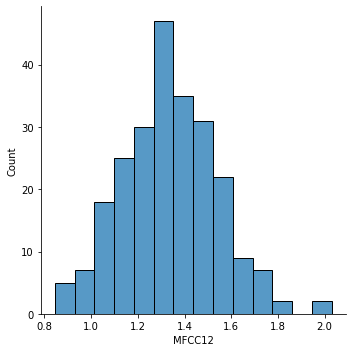

In [45]:
sns.displot(df["MFCC12"])

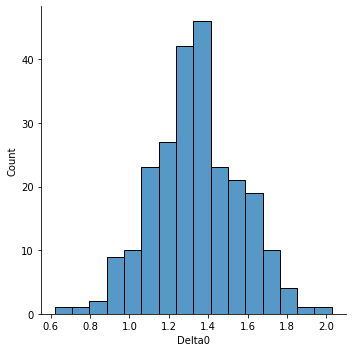

In [46]:
sns.displot(df["Delta0"])

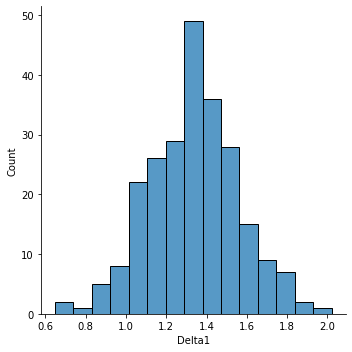

In [47]:
sns.displot(df["Delta1"])

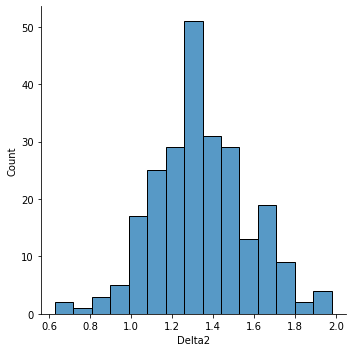

In [48]:
sns.displot(df["Delta2"])

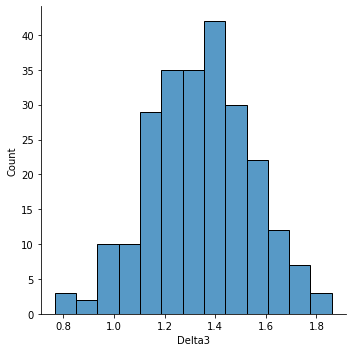

In [49]:
sns.displot(df["Delta3"])

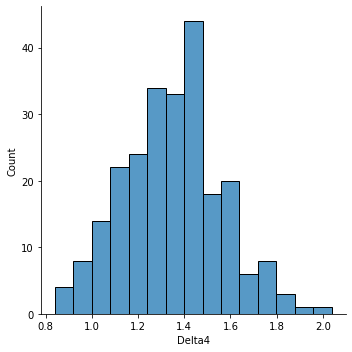

In [50]:
sns.displot(df["Delta4"])

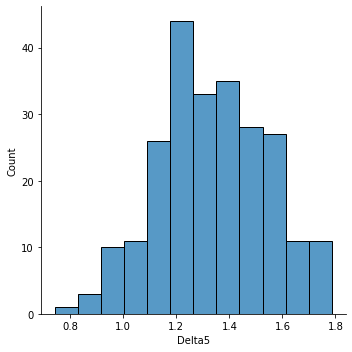

In [51]:
sns.displot(df["Delta5"])

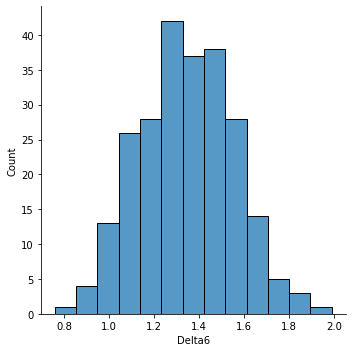

In [52]:
sns.displot(df["Delta6"])

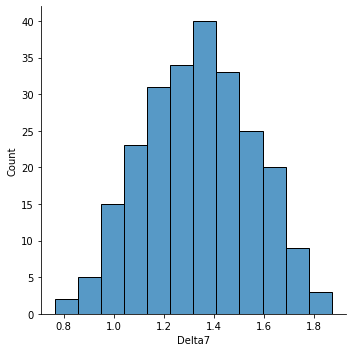

In [53]:
sns.displot(df["Delta7"])

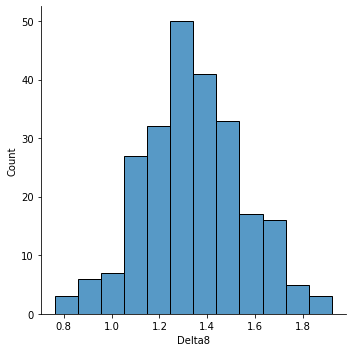

In [54]:
sns.displot(df["Delta8"])

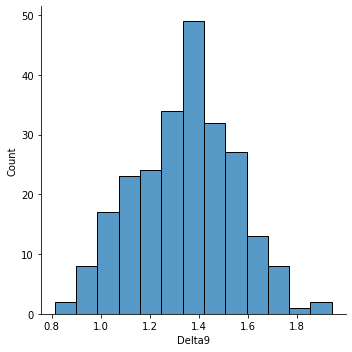

In [55]:
sns.displot(df["Delta9"])

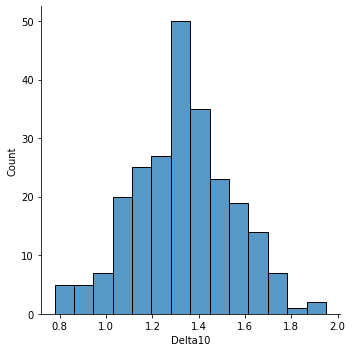

In [56]:
sns.displot(df["Delta10"])

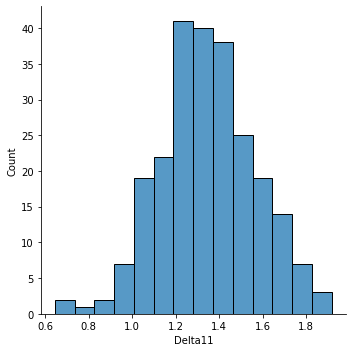

In [57]:
sns.displot(df["Delta11"])

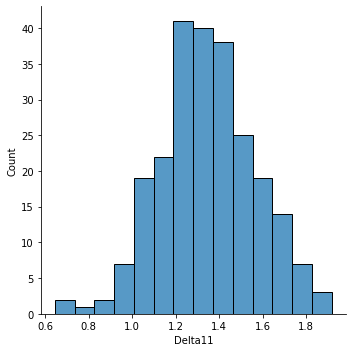

In [58]:
sns.displot(df["Delta11"])

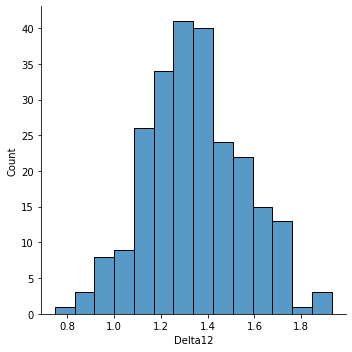

In [59]:
sns.displot(df["Delta12"])

# 4.Splitting the dataset into train and test data.(80:20 ratio)

In [60]:
#X=Train data
#y=test data
#We drop features from the dataset based on the correlation function we have created.Features that have a correlation value 
#of more than 0.85 can be dropped as it means they have a very strong relationship with other features and can hence be dropped.



X=df.drop('Status',axis=1)
y=df['Status']
cols=X.columns
print(cols)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)


Index(['Jitter_rel', 'Jitter_abs', 'Jitter_RAP', 'Jitter_PPQ', 'Shim_loc',
       'Shim_dB', 'Shim_APQ3', 'Shim_APQ5', 'Shi_APQ11', 'HNR05', 'HNR15',
       'HNR25', 'HNR35', 'HNR38', 'RPDE', 'DFA', 'PPE', 'GNE', 'MFCC0',
       'MFCC1', 'MFCC2', 'MFCC3', 'MFCC4', 'MFCC5', 'MFCC6', 'MFCC7', 'MFCC8',
       'MFCC9', 'MFCC10', 'MFCC11', 'MFCC12', 'Delta0', 'Delta1', 'Delta2',
       'Delta3', 'Delta4', 'Delta5', 'Delta6', 'Delta7', 'Delta8', 'Delta9',
       'Delta10', 'Delta11', 'Delta12'],
      dtype='object')


In [61]:
X_train=X_train.drop(corr_features,axis=1)
X_test=X_test.drop(corr_features,axis=1)

In [62]:
X_train.head()

,Jitter_rel,Shim_loc,HNR05,RPDE,DFA,PPE,GNE,MFCC0,MFCC1,MFCC2,...,Delta2,Delta3,Delta4,Delta5,Delta7,Delta8,Delta9,Delta10,Delta11,Delta12
76,0.64831,0.039959,58.066182,0.296943,0.637188,0.246862,0.875786,1.301046,1.379835,1.179867,...,1.322800,1.332889,1.300808,1.384125,1.424791,1.220446,1.268139,1.390144,1.204407,1.194025
146,0.22349,0.020352,51.902880,0.206423,0.523807,0.004492,0.950773,1.414416,1.406098,1.427245,...,1.426688,1.261495,1.376094,1.402522,1.251745,1.420849,1.445769,1.465932,1.213471,1.340034
216,1.33560,0.092608,54.891899,0.408607,0.626559,0.763914,0.891799,1.161743,1.223706,1.268690,...,1.358537,1.340927,1.294884,1.356211,1.391290,1.356018,1.387350,1.363523,1.407348,1.226665
49,0.62280,0.033902,49.474334,0.261930,0.615872,0.222938,0.914058,1.268242,1.250013,1.236930,...,1.274198,1.298653,1.271047,1.313834,1.315975,1.286136,1.272258,1.256734,1.269885,1.229270
1,0.29320,0.024716,62.179573,0.261360,0.625216,0.030518,0.875984,1.495235,1.602983,1.572715,...,1.309647,1.501200,1.534170,1.323993,1.472926,1.643177,1.551286,1.638346,1.604008,1.621456


In [63]:
X_test.head()

,Jitter_rel,Shim_loc,HNR05,RPDE,DFA,PPE,GNE,MFCC0,MFCC1,MFCC2,...,Delta2,Delta3,Delta4,Delta5,Delta7,Delta8,Delta9,Delta10,Delta11,Delta12
184,0.38118,0.035566,64.339515,0.284657,0.634009,0.513735,0.904149,1.251194,1.529233,1.500725,...,1.381389,1.498255,1.440484,1.506446,1.493222,1.571555,1.353944,1.472453,1.395885,1.485624
98,0.21683,0.019845,55.153492,0.233340,0.583393,0.005155,0.932549,1.400444,1.160015,1.073794,...,1.329214,1.394917,1.232179,1.244882,1.228878,1.282926,1.318402,1.300954,1.388881,1.467716
129,1.47270,0.087788,46.103301,0.390463,0.627367,0.449779,0.878673,1.050102,1.062831,1.013583,...,1.102575,1.147228,1.151371,1.030523,1.030494,1.104484,1.084525,1.072280,1.063936,0.986417
159,0.45376,0.064605,60.096871,0.341671,0.638666,0.736968,0.903977,1.296298,1.269313,1.314609,...,1.295076,1.327629,1.349928,1.461323,1.346363,1.415338,1.361937,1.331923,1.423062,1.307353
26,0.89185,0.048051,79.412370,0.347697,0.744930,0.249791,0.916356,1.597613,0.793130,0.717444,...,1.608281,1.655939,1.731073,1.627931,1.635282,1.712611,1.279860,1.575768,1.522019,1.480044


In [64]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Status, dtype: int64

# 5.Scale the data: Removing large variation in the columns of the dataset

In [65]:
cols=X_train.columns
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(X_train)
test_scaled = scaler.fit_transform(X_test)

X_train_scaled = pd.DataFrame(train_scaled)
X_test_scaled = pd.DataFrame(test_scaled)

# Replace the Columns Headers back
X_train_scaled.columns = cols
X_test_scaled.columns = cols
X_train_scaled.head()

,Jitter_rel,Shim_loc,HNR05,RPDE,DFA,PPE,GNE,MFCC0,MFCC1,MFCC2,...,Delta2,Delta3,Delta4,Delta5,Delta7,Delta8,Delta9,Delta10,Delta11,Delta12
0,0.074781,0.175609,0.453795,0.359550,0.605413,0.268413,0.203442,0.408469,0.601255,0.449164,...,0.544037,0.503452,0.454594,0.568244,0.553130,0.385972,0.385254,0.536365,0.473390,0.313397
1,0.011282,0.069714,0.375760,0.116992,0.301456,0.000378,0.739126,0.511950,0.625388,0.631199,...,0.626871,0.429243,0.535187,0.588010,0.380523,0.587675,0.563085,0.602664,0.481035,0.464461
2,0.177512,0.459958,0.413605,0.658766,0.576917,0.840220,0.317838,0.281316,0.457787,0.514526,...,0.572531,0.511808,0.448252,0.538253,0.519714,0.522423,0.504599,0.513077,0.644555,0.347167
3,0.070968,0.142896,0.345012,0.265729,0.548268,0.241956,0.476842,0.378526,0.481960,0.491155,...,0.505284,0.467866,0.422735,0.492724,0.444590,0.452088,0.389378,0.419659,0.528616,0.349862
4,0.021702,0.093284,0.505875,0.264202,0.573318,0.029159,0.204861,0.585720,0.806308,0.738244,...,0.533550,0.678402,0.704406,0.503639,0.601142,0.811446,0.668721,0.753492,0.810422,0.755625


In [66]:
X_test_scaled.head()

,Jitter_rel,Shim_loc,HNR05,RPDE,DFA,PPE,GNE,MFCC0,MFCC1,MFCC2,...,Delta2,Delta3,Delta4,Delta5,Delta7,Delta8,Delta9,Delta10,Delta11,Delta12
0,0.122425,0.296929,0.676984,0.431850,0.546869,0.593292,0.347827,0.466703,0.714197,0.682577,...,0.557264,0.668839,0.501082,0.797835,0.694764,0.698810,0.479059,0.557926,0.544330,0.623862
1,0.009642,0.085275,0.511861,0.222336,0.373463,0.001197,0.613658,0.611504,0.369819,0.310535,...,0.518666,0.574391,0.327221,0.524957,0.442687,0.449419,0.447644,0.399059,0.538222,0.608708
2,0.871468,1.000000,0.349179,0.863822,0.524116,0.518834,0.109370,0.271605,0.279174,0.258066,...,0.351003,0.348011,0.259775,0.301326,0.253509,0.295236,0.240927,0.187228,0.254843,0.201411
3,0.172232,0.687885,0.600720,0.664616,0.562825,0.853183,0.346219,0.510463,0.471764,0.520390,...,0.493411,0.512892,0.425500,0.750760,0.554720,0.563830,0.486124,0.427746,0.568031,0.473001
4,0.472866,0.465016,0.947926,0.689222,0.926878,0.286006,0.462090,0.802796,0.027617,0.000000,...,0.725114,0.812957,0.743623,0.924575,0.830232,0.820691,0.413578,0.653630,0.654330,0.619140


In [67]:
numrows = X_train_scaled.count(axis=0)[0]
print("Total no. of rows in the training set: ", numrows)
numrowstest = X_test_scaled.count(axis=0)[0]
print("Total no. of rows in the testing set: ", numrowstest)

Total no. of rows in the training set:  192
Total no. of rows in the testing set:  48


# 6.Classification using various models

In [68]:
# A Dataframe to store Model Performance Results
perf_column_name = ['Model','Train Accu','Test Accu','F1-Score','Recall','AUC']
perfDF = pd.DataFrame(columns = perf_column_name)

#Function to collect and add Model Performance Results
def BuildPerformanceData(model, modelname, y_predict, perfDF):
    class_rep = classification_report(y_test,y_predict, output_dict=True)
        #AUC Calculations
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_predict, pos_label=1)
    arg1 = round(model.score(X_train_scaled,y_train) * 100,2)
    arg2 = round(model.score(X_test_scaled,y_test) * 100,2)
    arg4 = round(class_rep['1']['f1-score'] * 100, 2)
    arg5 = round(class_rep['1']['recall'] * 100,2)
    arg6 = round(metrics.auc(fpr, tpr)*100,2)
    perfDF = perfDF.append({'Model':modelname,'Train Accu':arg1,'Test Accu':arg2, 'F1-Score':arg4,'Recall':arg5,'AUC':arg6},ignore_index=True)
    return perfDF

#Function to print Confusion Matrix and Classification Report
def Print_CM_CR_AUC(y_test,y_predict, algoname):
    cm = confusion_matrix(y_test,y_predict)
    sns.heatmap(cm,annot=True, fmt='.2f', xticklabels=[0,1], yticklabels=[0,1])
    plt.ylabel('observed')
    plt.xlabel('Predicted')
    plt.show()
    # get accuracy of model
    acc_score = accuracy_score(y_test,y_predict)
    # get F1-score of model
    F1_score = f1_score(y_test,y_predict) 
    # get the classification report
    class_rep = classification_report(y_test,y_predict)

    print("Accuracy of ", algoname, " is {} %".format(acc_score*100))
    print("F1-score of ", algoname, " is {} %".format(F1_score*100))
    print("Classification report for ", algoname, " is: \n",class_rep)
    
    #AUC Calculations
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_predict, pos_label=1)
    print("AUC for ", algoname, ":", round(metrics.auc(fpr, tpr)*100,2))

# KNN :

In [69]:
error_rate = []

for i in range(1,100):
 NNH = KNeighborsClassifier(n_neighbors=i)
 NNH.fit(X_train_scaled,y_train)
 KNN_predicted_labels = NNH.predict(X_test_scaled)
 error_rate.append(np.mean(KNN_predicted_labels != y_test))

Text(0, 0.5, 'Error Rate')

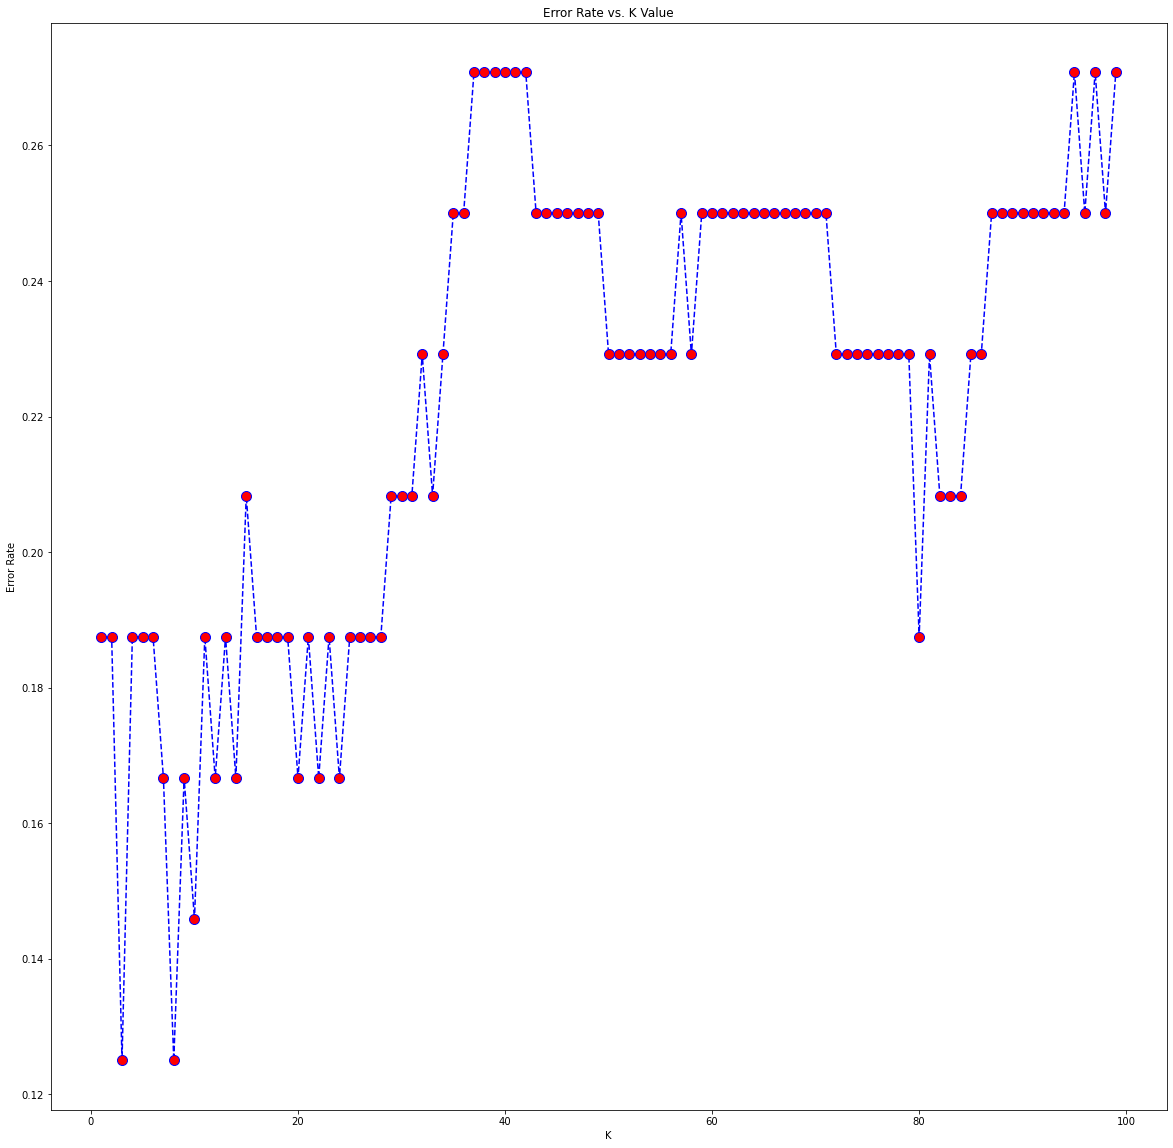

In [70]:
plt.figure(figsize=(20,20))
plt.plot(range(1,100),error_rate,color= 'blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

# Observation: K=5 should be good number for KNN as that's the first sharp elbow.

In [71]:
K = 5

NNH = KNeighborsClassifier(n_neighbors= K)

# Call Nearest Neighbour algorithm
NNH.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [72]:
#Predict using the test data and store the result 

KNN_predicted_labels = NNH.predict(X_train_scaled)
train_acc = metrics.accuracy_score(y_train, KNN_predicted_labels)
print("Model Accuracy with Training Data: {0:.4f}".format(metrics.accuracy_score(y_train, KNN_predicted_labels)*100))
print()

KNN_predicted_labels = NNH.predict(X_test_scaled)
test_acc = metrics.accuracy_score(y_test, KNN_predicted_labels)
print("Model Accuracy with Testing Data: {0:.4f}".format(metrics.accuracy_score(y_test, KNN_predicted_labels)*100))
print()

Model Accuracy with Training Data: 81.7708

Model Accuracy with Testing Data: 81.2500



# SVM:

In [73]:
C = 100
gamma=0.001
SVCL = svm.SVC(C=C,gamma=gamma)
SVCL.fit(X_train_scaled , y_train)
SVC_Predicted_labels = SVCL.predict(X_train_scaled)

print("Model Accuracy with Training Data: {0:.4f}".format(metrics.accuracy_score(y_train, SVC_Predicted_labels)*100))
print()

SVC_Predicted_labels = SVCL.predict(X_test_scaled)

print("Model Accuracy with Testing Data: {0:.4f}".format(metrics.accuracy_score(y_test, SVC_Predicted_labels)*100))
print()

Model Accuracy with Training Data: 82.8125

Model Accuracy with Testing Data: 79.1667



# NAIVE BAYES METHOD:

In [74]:
# creat the model
GNB = GaussianNB()
GNB.fit(X_train_scaled, y_train)
GNB_predicted_labels = GNB.predict(X_train_scaled)

print("Model Accuracy with Training Data: {0:.4f}".format(metrics.accuracy_score(y_train, GNB_predicted_labels)*100))
print()

GNB_predicted_labels = GNB.predict(X_test_scaled)

print("Model Accuracy with Testing data: {0:.4f}".format(metrics.accuracy_score(y_test, GNB_predicted_labels)*100))
print()

Model Accuracy with Training Data: 80.7292

Model Accuracy with Testing data: 70.8333



# LOGISTIC REGRESSION:

In [75]:
# Fit the model on train
LR = LogisticRegression(solver="liblinear")
LR.fit(X_train_scaled, y_train)
LR_predicted_labels = LR.predict(X_train_scaled)

print("Model Accuracy with Training Data: {0:.4f}".format(metrics.accuracy_score(y_train, LR_predicted_labels)*100))
print()

LR_predicted_labels = LR.predict(X_test_scaled)

print("Model Accuracy with Testing data: {0:.4f}".format(metrics.accuracy_score(y_test, LR_predicted_labels)*100))
print()

Model Accuracy with Training Data: 83.8542

Model Accuracy with Testing data: 83.3333



# CONFUSION MATRIX:

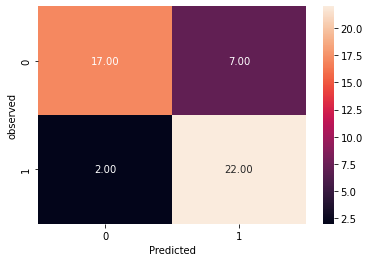

Accuracy of  KNN  is 81.25 %
F1-score of  KNN  is 83.0188679245283 %
Classification report for  KNN  is: 
               precision    recall  f1-score   support

           0       0.89      0.71      0.79        24
           1       0.76      0.92      0.83        24

    accuracy                           0.81        48
   macro avg       0.83      0.81      0.81        48
weighted avg       0.83      0.81      0.81        48

AUC for  KNN : 81.25


C:\Users\Admin4\AppData\Local\Temp\ipykernel_14264\2509579015.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  perfDF = perfDF.append({'Model':modelname,'Train Accu':arg1,'Test Accu':arg2, 'F1-Score':arg4,'Recall':arg5,'AUC':arg6},ignore_index=True)


,Model,Train Accu,Test Accu,F1-Score,Recall,AUC
0,KNN,81.77,81.25,83.02,91.67,81.25


In [76]:
#Draw Confusion Matrix and Classification Report for KNN
Print_CM_CR_AUC(y_test,KNN_predicted_labels, "KNN")
perfDF = BuildPerformanceData(NNH, "KNN", KNN_predicted_labels, perfDF)
perfDF

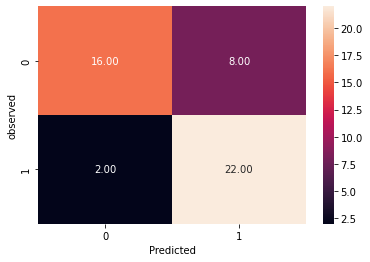

Accuracy of  SVC  is 79.16666666666666 %
F1-score of  SVC  is 81.48148148148148 %
Classification report for  SVC  is: 
               precision    recall  f1-score   support

           0       0.89      0.67      0.76        24
           1       0.73      0.92      0.81        24

    accuracy                           0.79        48
   macro avg       0.81      0.79      0.79        48
weighted avg       0.81      0.79      0.79        48

AUC for  SVC : 79.17


C:\Users\Admin4\AppData\Local\Temp\ipykernel_14264\2509579015.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  perfDF = perfDF.append({'Model':modelname,'Train Accu':arg1,'Test Accu':arg2, 'F1-Score':arg4,'Recall':arg5,'AUC':arg6},ignore_index=True)


,Model,Train Accu,Test Accu,F1-Score,Recall,AUC
0,KNN,81.77,81.25,83.02,91.67,81.25
1,SVC,82.81,79.17,81.48,91.67,79.17


In [77]:
#Draw Confusion Matrix and Classification Report for SVM
Print_CM_CR_AUC(y_test,SVC_Predicted_labels, "SVC")
perfDF = BuildPerformanceData(SVCL, "SVC", SVC_Predicted_labels, perfDF)
perfDF

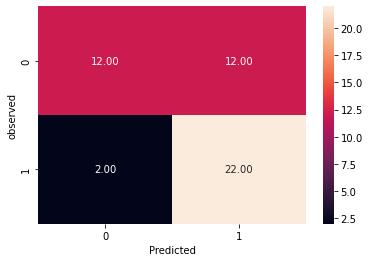

Accuracy of  Naive Bayes  is 70.83333333333334 %
F1-score of  Naive Bayes  is 75.86206896551724 %
Classification report for  Naive Bayes  is: 
               precision    recall  f1-score   support

           0       0.86      0.50      0.63        24
           1       0.65      0.92      0.76        24

    accuracy                           0.71        48
   macro avg       0.75      0.71      0.70        48
weighted avg       0.75      0.71      0.70        48

AUC for  Naive Bayes : 70.83


C:\Users\Admin4\AppData\Local\Temp\ipykernel_14264\2509579015.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  perfDF = perfDF.append({'Model':modelname,'Train Accu':arg1,'Test Accu':arg2, 'F1-Score':arg4,'Recall':arg5,'AUC':arg6},ignore_index=True)


,Model,Train Accu,Test Accu,F1-Score,Recall,AUC
0,KNN,81.77,81.25,83.02,91.67,81.25
1,SVC,82.81,79.17,81.48,91.67,79.17
2,Naive Bayes,80.73,70.83,75.86,91.67,70.83


In [78]:
#Draw Confusion Matrix and Classification Report for Naive Bayes
Print_CM_CR_AUC(y_test,GNB_predicted_labels, "Naive Bayes")
perfDF = BuildPerformanceData(GNB, "Naive Bayes", GNB_predicted_labels, perfDF)
perfDF

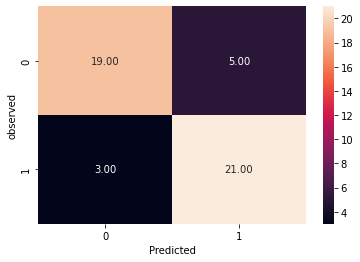

Accuracy of  Logistic Regression  is 83.33333333333334 %
F1-score of  Logistic Regression  is 84.00000000000001 %
Classification report for  Logistic Regression  is: 
               precision    recall  f1-score   support

           0       0.86      0.79      0.83        24
           1       0.81      0.88      0.84        24

    accuracy                           0.83        48
   macro avg       0.84      0.83      0.83        48
weighted avg       0.84      0.83      0.83        48

AUC for  Logistic Regression : 83.33


C:\Users\Admin4\AppData\Local\Temp\ipykernel_14264\2509579015.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  perfDF = perfDF.append({'Model':modelname,'Train Accu':arg1,'Test Accu':arg2, 'F1-Score':arg4,'Recall':arg5,'AUC':arg6},ignore_index=True)


,Model,Train Accu,Test Accu,F1-Score,Recall,AUC
0,KNN,81.77,81.25,83.02,91.67,81.25
1,SVC,82.81,79.17,81.48,91.67,79.17
2,Naive Bayes,80.73,70.83,75.86,91.67,70.83
3,Logistic Regression,83.85,83.33,84.0,87.5,83.33


In [79]:
#Draw Confusion Matrix and Classification Report for Logistic Regression
Print_CM_CR_AUC(y_test,LR_predicted_labels, "Logistic Regression")
perfDF = BuildPerformanceData(LR, "Logistic Regression", LR_predicted_labels, perfDF)
perfDF

# 7 META CLASSIFIER 

In [80]:
estimators = [
    ('knn', KNeighborsClassifier(n_neighbors= K)),
     ('svm', svm.SVC(gamma=gamma, C=C)),
     ('gnb', GaussianNB()),
     ('lr', LogisticRegression(solver="liblinear"))
]

STCL = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

STCL.fit(X_train_scaled, y_train)

print("Model Accuracy with Training Data: {0:.4f}".format(STCL.score(X_train_scaled,y_train)*100))
print()

print("Model Accuracy with Testing Data: {0:.4f}".format(STCL.score(X_test_scaled,y_test)*100))
print()

STCL_predicted_labels = STCL.predict(X_test_scaled)

Model Accuracy with Training Data: 82.8125

Model Accuracy with Testing Data: 75.0000



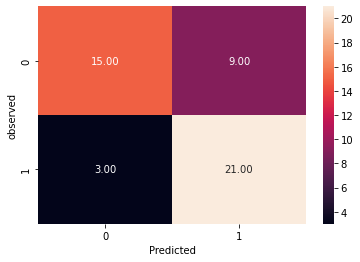

Accuracy of  Meta Classifier  is 75.0 %
F1-score of  Meta Classifier  is 77.77777777777777 %
Classification report for  Meta Classifier  is: 
               precision    recall  f1-score   support

           0       0.83      0.62      0.71        24
           1       0.70      0.88      0.78        24

    accuracy                           0.75        48
   macro avg       0.77      0.75      0.75        48
weighted avg       0.77      0.75      0.75        48

AUC for  Meta Classifier : 75.0


C:\Users\Admin4\AppData\Local\Temp\ipykernel_14264\2509579015.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  perfDF = perfDF.append({'Model':modelname,'Train Accu':arg1,'Test Accu':arg2, 'F1-Score':arg4,'Recall':arg5,'AUC':arg6},ignore_index=True)


,Model,Train Accu,Test Accu,F1-Score,Recall,AUC
0,KNN,81.77,81.25,83.02,91.67,81.25
1,SVC,82.81,79.17,81.48,91.67,79.17
2,Naive Bayes,80.73,70.83,75.86,91.67,70.83
3,Logistic Regression,83.85,83.33,84.0,87.5,83.33
4,Meta Classifier,82.81,75.0,77.78,87.5,75.0


In [81]:
#Draw Confusion Matrix and Classification Report for Logistic Regression
Print_CM_CR_AUC(y_test,STCL_predicted_labels, "Meta Classifier")
perfDF = BuildPerformanceData(STCL, "Meta Classifier", STCL_predicted_labels, perfDF)
perfDF

# TRAINING ENSEMBLE MODELS:

In [82]:
dTree = DecisionTreeClassifier(criterion = 'gini', max_depth = 2, random_state=1)
dTree.fit(X_train_scaled, y_train)
print("Model Accuracy with Training Data: {0:.4f}".format(dTree.score(X_train_scaled,y_train)*100))
print()

print("Model Accuracy with Testing Data: {0:.4f}".format(dTree.score(X_test_scaled,y_test)*100))
print()

dTree_predicted_labels = dTree.predict(X_test_scaled)

Model Accuracy with Training Data: 81.2500

Model Accuracy with Testing Data: 75.0000



In [83]:
from sklearn.ensemble import BaggingClassifier
BGCL = BaggingClassifier(base_estimator=dTree, n_estimators=50,random_state=1)
#bgcl = BaggingClassifier(n_estimators=50,random_state=1)
BGCL.fit(X_train_scaled, y_train)

print("Model Accuracy with Training Data: {0:.4f}".format(BGCL.score(X_train_scaled,y_train)*100))
print()

print("Model Accuracy with Testing Data: {0:.4f}".format(BGCL.score(X_test_scaled,y_test)*100))
print()

BGCL_predicted_labels = BGCL.predict(X_test_scaled)

Model Accuracy with Training Data: 82.8125

Model Accuracy with Testing Data: 77.0833



In [84]:
ABCL = AdaBoostClassifier(n_estimators=10, random_state=1)
ABCL.fit(X_train_scaled, y_train)

print("Model Accuracy with Training Data: {0:.4f}".format(ABCL.score(X_train_scaled,y_train)*100))
print()

print("Model Accuracy with Testing Data: {0:.4f}".format(ABCL.score(X_test_scaled,y_test)*100))
print()

ABCL_predicted_labels = ABCL.predict(X_test_scaled)

Model Accuracy with Training Data: 88.0208

Model Accuracy with Testing Data: 75.0000



In [85]:
GBCL = GradientBoostingClassifier(n_estimators = 10,random_state=1)
GBCL.fit(X_train_scaled, y_train)

print("Model Accuracy with Training Data: {0:.4f}".format(GBCL.score(X_train_scaled,y_train)*100))
print()

print("Model Accuracy with Testing Data: {0:.4f}".format(GBCL.score(X_test_scaled,y_test)*100))
print()

GBCL_predicted_labels = GBCL.predict(X_test_scaled)

Model Accuracy with Training Data: 90.1042

Model Accuracy with Testing Data: 70.8333



In [86]:
RFCL = RandomForestClassifier(n_estimators = 10, random_state=1,max_features=10)
RFCL.fit(X_train_scaled, y_train)

print("Model Accuracy with Training Data: {0:.4f}".format(RFCL.score(X_train_scaled,y_train)*100))
print()

print("Model Accuracy with Testing Data: {0:.4f}".format(RFCL.score(X_test_scaled,y_test)*100))
print()

RFCL_predicted_labels = RFCL.predict(X_test_scaled)

Model Accuracy with Training Data: 99.4792

Model Accuracy with Testing Data: 77.0833



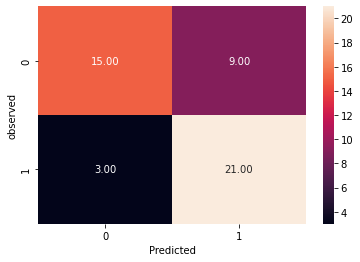

Accuracy of  Decision Tree  is 75.0 %
F1-score of  Decision Tree  is 77.77777777777777 %
Classification report for  Decision Tree  is: 
               precision    recall  f1-score   support

           0       0.83      0.62      0.71        24
           1       0.70      0.88      0.78        24

    accuracy                           0.75        48
   macro avg       0.77      0.75      0.75        48
weighted avg       0.77      0.75      0.75        48

AUC for  Decision Tree : 75.0


C:\Users\Admin4\AppData\Local\Temp\ipykernel_14264\2509579015.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  perfDF = perfDF.append({'Model':modelname,'Train Accu':arg1,'Test Accu':arg2, 'F1-Score':arg4,'Recall':arg5,'AUC':arg6},ignore_index=True)


,Model,Train Accu,Test Accu,F1-Score,Recall,AUC
0,KNN,81.77,81.25,83.02,91.67,81.25
1,SVC,82.81,79.17,81.48,91.67,79.17
2,Naive Bayes,80.73,70.83,75.86,91.67,70.83
3,Logistic Regression,83.85,83.33,84.0,87.5,83.33
4,Meta Classifier,82.81,75.0,77.78,87.5,75.0
5,Decision Tree,81.25,75.0,77.78,87.5,75.0


In [87]:
#Draw Confusion Matrix and Classification Report for Decision Tree
Print_CM_CR_AUC(y_test,dTree_predicted_labels, "Decision Tree")
perfDF = BuildPerformanceData(dTree, "Decision Tree", dTree_predicted_labels, perfDF)
perfDF

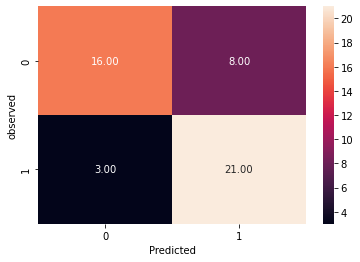

Accuracy of  Bagging  is 77.08333333333334 %
F1-score of  Bagging  is 79.24528301886792 %
Classification report for  Bagging  is: 
               precision    recall  f1-score   support

           0       0.84      0.67      0.74        24
           1       0.72      0.88      0.79        24

    accuracy                           0.77        48
   macro avg       0.78      0.77      0.77        48
weighted avg       0.78      0.77      0.77        48

AUC for  Bagging : 77.08


C:\Users\Admin4\AppData\Local\Temp\ipykernel_14264\2509579015.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  perfDF = perfDF.append({'Model':modelname,'Train Accu':arg1,'Test Accu':arg2, 'F1-Score':arg4,'Recall':arg5,'AUC':arg6},ignore_index=True)


,Model,Train Accu,Test Accu,F1-Score,Recall,AUC
0,KNN,81.77,81.25,83.02,91.67,81.25
1,SVC,82.81,79.17,81.48,91.67,79.17
2,Naive Bayes,80.73,70.83,75.86,91.67,70.83
3,Logistic Regression,83.85,83.33,84.0,87.5,83.33
4,Meta Classifier,82.81,75.0,77.78,87.5,75.0
5,Decision Tree,81.25,75.0,77.78,87.5,75.0
6,Bagging,82.81,77.08,79.25,87.5,77.08


In [88]:
#Draw Confusion Matrix and Classification Report for Bagging
Print_CM_CR_AUC(y_test,BGCL_predicted_labels, "Bagging")
perfDF = BuildPerformanceData(BGCL, "Bagging", BGCL_predicted_labels, perfDF)
perfDF

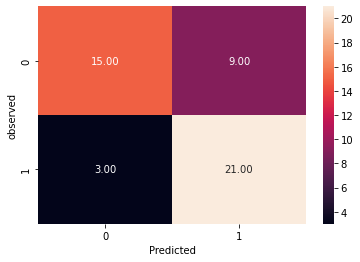

Accuracy of  AdaBoost  is 75.0 %
F1-score of  AdaBoost  is 77.77777777777777 %
Classification report for  AdaBoost  is: 
               precision    recall  f1-score   support

           0       0.83      0.62      0.71        24
           1       0.70      0.88      0.78        24

    accuracy                           0.75        48
   macro avg       0.77      0.75      0.75        48
weighted avg       0.77      0.75      0.75        48

AUC for  AdaBoost : 75.0


C:\Users\Admin4\AppData\Local\Temp\ipykernel_14264\2509579015.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  perfDF = perfDF.append({'Model':modelname,'Train Accu':arg1,'Test Accu':arg2, 'F1-Score':arg4,'Recall':arg5,'AUC':arg6},ignore_index=True)


,Model,Train Accu,Test Accu,F1-Score,Recall,AUC
0,KNN,81.77,81.25,83.02,91.67,81.25
1,SVC,82.81,79.17,81.48,91.67,79.17
2,Naive Bayes,80.73,70.83,75.86,91.67,70.83
3,Logistic Regression,83.85,83.33,84.0,87.5,83.33
4,Meta Classifier,82.81,75.0,77.78,87.5,75.0
5,Decision Tree,81.25,75.0,77.78,87.5,75.0
6,Bagging,82.81,77.08,79.25,87.5,77.08
7,AdaBoost,88.02,75.0,77.78,87.5,75.0


In [89]:
#Draw Confusion Matrix and Classification Report for AdaBoost
Print_CM_CR_AUC(y_test,ABCL_predicted_labels, "AdaBoost")
perfDF = BuildPerformanceData(ABCL, "AdaBoost", ABCL_predicted_labels, perfDF)
perfDF

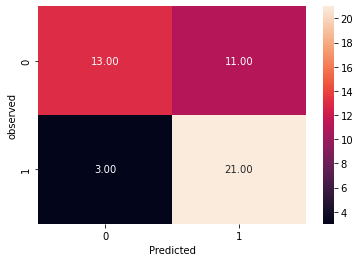

Accuracy of  Gradiaent Boost  is 70.83333333333334 %
F1-score of  Gradiaent Boost  is 75.0 %
Classification report for  Gradiaent Boost  is: 
               precision    recall  f1-score   support

           0       0.81      0.54      0.65        24
           1       0.66      0.88      0.75        24

    accuracy                           0.71        48
   macro avg       0.73      0.71      0.70        48
weighted avg       0.73      0.71      0.70        48

AUC for  Gradiaent Boost : 70.83


C:\Users\Admin4\AppData\Local\Temp\ipykernel_14264\2509579015.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  perfDF = perfDF.append({'Model':modelname,'Train Accu':arg1,'Test Accu':arg2, 'F1-Score':arg4,'Recall':arg5,'AUC':arg6},ignore_index=True)


,Model,Train Accu,Test Accu,F1-Score,Recall,AUC
0,KNN,81.77,81.25,83.02,91.67,81.25
1,SVC,82.81,79.17,81.48,91.67,79.17
2,Naive Bayes,80.73,70.83,75.86,91.67,70.83
3,Logistic Regression,83.85,83.33,84.0,87.5,83.33
4,Meta Classifier,82.81,75.0,77.78,87.5,75.0
5,Decision Tree,81.25,75.0,77.78,87.5,75.0
6,Bagging,82.81,77.08,79.25,87.5,77.08
7,AdaBoost,88.02,75.0,77.78,87.5,75.0
8,Gradiaent Boost,90.1,70.83,75.0,87.5,70.83


In [90]:
#Draw Confusion Matrix and Classification Report for Gradient Boost
Print_CM_CR_AUC(y_test,GBCL_predicted_labels, "Gradiaent Boost")
perfDF = BuildPerformanceData(GBCL, "Gradiaent Boost", GBCL_predicted_labels, perfDF)
perfDF

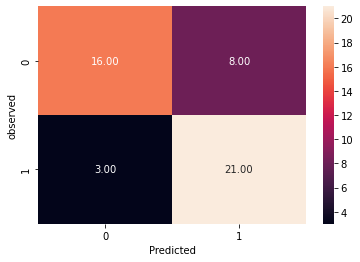

Accuracy of  Random Forest  is 77.08333333333334 %
F1-score of  Random Forest  is 79.24528301886792 %
Classification report for  Random Forest  is: 
               precision    recall  f1-score   support

           0       0.84      0.67      0.74        24
           1       0.72      0.88      0.79        24

    accuracy                           0.77        48
   macro avg       0.78      0.77      0.77        48
weighted avg       0.78      0.77      0.77        48

AUC for  Random Forest : 77.08


C:\Users\Admin4\AppData\Local\Temp\ipykernel_14264\2509579015.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  perfDF = perfDF.append({'Model':modelname,'Train Accu':arg1,'Test Accu':arg2, 'F1-Score':arg4,'Recall':arg5,'AUC':arg6},ignore_index=True)


,Model,Train Accu,Test Accu,F1-Score,Recall,AUC
0,KNN,81.77,81.25,83.02,91.67,81.25
1,SVC,82.81,79.17,81.48,91.67,79.17
2,Naive Bayes,80.73,70.83,75.86,91.67,70.83
3,Logistic Regression,83.85,83.33,84.0,87.5,83.33
4,Meta Classifier,82.81,75.0,77.78,87.5,75.0
5,Decision Tree,81.25,75.0,77.78,87.5,75.0
6,Bagging,82.81,77.08,79.25,87.5,77.08
7,AdaBoost,88.02,75.0,77.78,87.5,75.0
8,Gradiaent Boost,90.1,70.83,75.0,87.5,70.83
9,Random Forest,99.48,77.08,79.25,87.5,77.08


In [91]:
#Draw Confusion Matrix and Classification Report for RandomForest
Print_CM_CR_AUC(y_test,RFCL_predicted_labels, "Random Forest")
perfDF = BuildPerformanceData(RFCL, "Random Forest", RFCL_predicted_labels, perfDF)
perfDF

# COMPARING ALL THE MODELS:

In [92]:
perfDF

,Model,Train Accu,Test Accu,F1-Score,Recall,AUC
0,KNN,81.77,81.25,83.02,91.67,81.25
1,SVC,82.81,79.17,81.48,91.67,79.17
2,Naive Bayes,80.73,70.83,75.86,91.67,70.83
3,Logistic Regression,83.85,83.33,84.0,87.5,83.33
4,Meta Classifier,82.81,75.0,77.78,87.5,75.0
5,Decision Tree,81.25,75.0,77.78,87.5,75.0
6,Bagging,82.81,77.08,79.25,87.5,77.08
7,AdaBoost,88.02,75.0,77.78,87.5,75.0
8,Gradiaent Boost,90.1,70.83,75.0,87.5,70.83
9,Random Forest,99.48,77.08,79.25,87.5,77.08
